In [17]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import os

In [23]:
from astropy import units as un, constants as cons
import numpy as np
import cooling_flow as CF
import HaloPotential as Halo
import matplotlib.pyplot as plt
import GrackleCooling as Cool
import AgoraPotential as Agora
from astropy import constants as const
from astropy import units as u
from scipy.interpolate import interp1d

In [3]:
plt.rcParams['font.size']=22
plt.rcParams['axes.linewidth']=2
plt.rcParams['xtick.major.size']=10
plt.rcParams['xtick.minor.size']=5
plt.rcParams['xtick.major.width']=2
plt.rcParams['xtick.minor.width']=1
plt.rcParams['xtick.direction']='in'
plt.rcParams['ytick.major.size']=10
plt.rcParams['ytick.minor.size']=5
plt.rcParams['ytick.major.width']=2
plt.rcParams['ytick.minor.width']=1
plt.rcParams['ytick.direction']='in'

In [4]:
Msun = 1.988409870698051e+33
G = 6.674299999999999e-08
mp = 1.67262192369e-24
kpc = 3.0856775814913673e+21
gamma = 5./3.
yr_to_sec = 3.154e+7
Myr = yr_to_sec * 1.e6
kmps = 1.e5
kb = 1.38e-16


In [8]:
Mvir=1.775e11*cons.M_sun #LMC Mass from Shah+
potential = Halo.NFW(Mvir=Mvir, z=0, cvir=10)
vc200 = potential.vc(potential.rvir())
vc200, Mvir

(<Quantity 71.75541213 km / s>, <Quantity 3.52942752e+41 kg>)

In [9]:
### Agora stellar Mass  = 3.385e10
#LMC stellar Mass = 2.5e9
Mdot_approx = (2.5e9/3.385e10)
Mdot_approx

0.07385524372230429

In [10]:
z = 0.
Z2Zsun = 0.5
table = "resampled_cooling_tables_0.5.h5"
cooling = Cool.GrackleCooling(Z2Zsun, z)

In [11]:
max_step = 0.1                         #lowest resolution of solution in ln(r)
R_min    = 0.9*un.kpc                  #inner radius of supersonic part of solution
R_max    = 1*potential.rvir()    #outer radius of integration
R_sonics  = np.array([0.36])*un.kpc  #sonic radii

In [12]:
transsonic_solutions = []
for R_sonic in R_sonics:
    print('R_sonic = %s'%R_sonic)
    transsonic_solutions.append(CF.shoot_from_sonic_point(potential,
                                                    cooling,
                                                    R_sonic,
                                                    R_max,
                                                    R_min,
                                                    max_step=max_step,
                                                    calcInwardSolution=False,
                                                    pr=True))
res = transsonic_solutions[0]             
print('Mdot =', res.Mdot.value )
print('Rmax =', np.amax(res.Rs()))

R_sonic = 0.36 kpc
Integrated with v_c^2/c_s^2 (R_sonic) =1.000010;  no transsonic solutions
Integrated with v_c^2/c_s^2 (R_sonic) =0.500015;  maximum r=17 kpc; stop reason: unbound
Integrated with v_c^2/c_s^2 (R_sonic) =0.750012;  maximum r=1 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.625014;  maximum r=7 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.562514;  

/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: overflow encountered in square
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in add
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


maximum r=86 kpc; stop reason: unbound
Integrated with v_c^2/c_s^2 (R_sonic) =0.593764;  maximum r=14 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.578139;  maximum r=23 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.570327;  

/Users/aditivijayan/quokka/INCITE/dwGal_setup/HaloProfile/cooling_flow_stern-19/cooling_flow.py:64: RuntimeWarning: overflow encountered in scalar power
  rho,T=e**ln_rho*un.g/un.cm**3, e**ln_T*un.K
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/aditivijayan/quokka/INCITE/dwGal_setup/HaloProfile/cooling_flow_stern-19/GalaxyIC_for_Quokka/GrackleCooling.py:100: RuntimeWarning: divide by zero encountered in log10
  return self.f_Cooling((log(T.to('K').value), log(nH.to('cm**-3').value))) * un.erg*un.cm**3/un.s
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: Runti

maximum r=34 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.566421;  maximum r=51 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.564467;  maximum r=81 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.563491;  maximum r=136 kpc; stop reason: unbound
Integrated with v_c^2/c_s^2 (R_sonic) =0.563979;  maximum r=107 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.563735;  maximum r=148 kpc; stop reason: max R reached
Mdot = 0.0018685732541220174
Rmax = 148.22861241934334 kpc


Rmax= 148.22861241934334 kpc
Average lambda= 1.654419411090616e-20


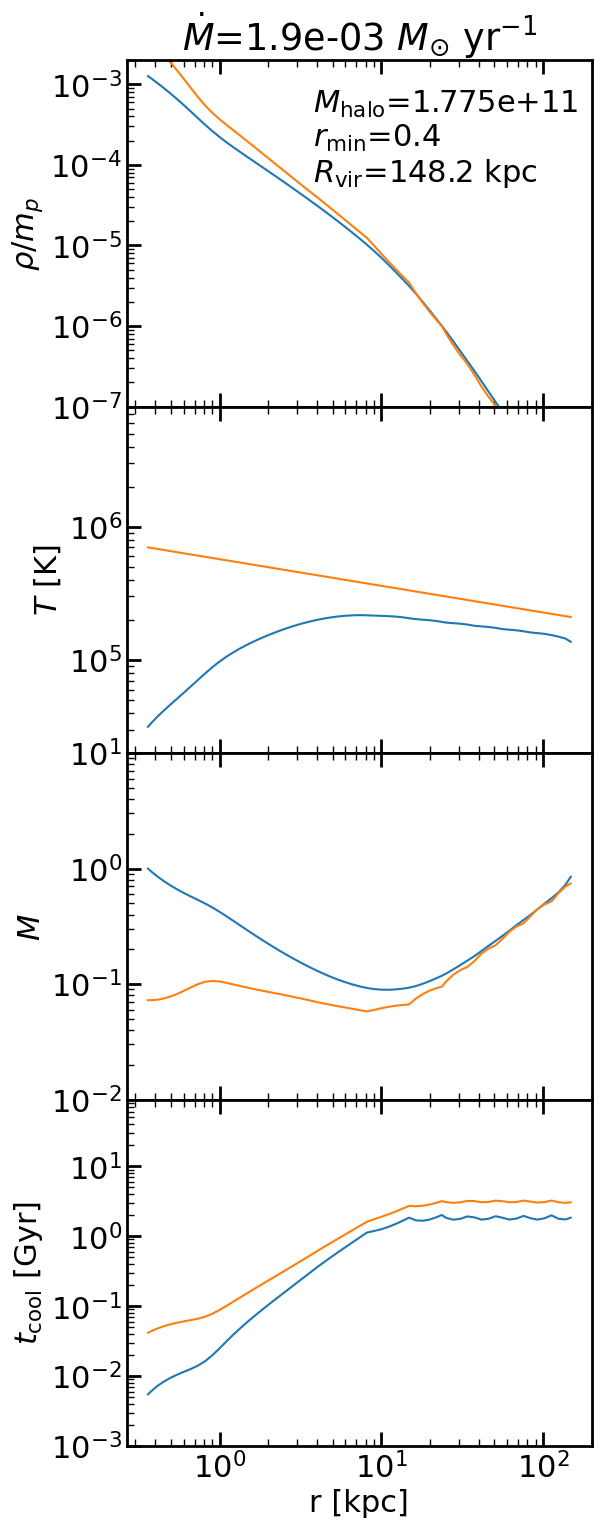

In [13]:
res = transsonic_solutions[0]
mu = 0.6
Mhalo = Mvir.to('g').value
X = 0.75

r = res.Rs()
Rvir = potential.rvir().value
print('Rmax=',np.amax(r))

rkpc = r.value
B = res.Bernoulli().value
rho = res.rhos().value
cs = res.cs().value
Mdot = res.Mdot.value * (Msun/yr_to_sec)
tcool = res.t_cools().value 
lambda_cool = np.abs(res.Lambdas().value)
print('Average lambda=',np.mean(lambda_cool))
v = res.vs().value
T = cs * cs * mu * mp * kmps * kmps/gamma/kb
gamma = 5./3.
v = Mdot/(4*np.pi*(rkpc*kpc)**2 * rho)
Mach = v/cs/kmps

Mach_anl = 0.11 * (Mhalo/(1.e12*Msun))**(-0.72) * (Mdot/(Msun/yr_to_sec))**(0.5) * (lambda_cool/1.e-22)**(0.5) * (r/100)**(-0.3) 
nH_anl   = 1.6e-5 * (Mhalo/(1.e12*Msun))**(0.36) * (Mdot/(Msun/yr_to_sec))**(0.5) *(lambda_cool/1.e-22)**(-0.5) * (r/100)**(-1.6)
tcool_anl = 7.2 * (Mhalo/(1.e12*Msun))**(0.36) * (Mdot/(Msun/yr_to_sec))**(-0.5) * (lambda_cool/1.e-22)**(-0.5) * (r/100)**(1.4) 
T_anl = X * mu * tcool_anl * (gamma-1) * nH_anl * lambda_cool * 1.e9 * yr_to_sec/kb 
Rsonic = 0.06 * (Mhalo/(1.e12*Msun))**(-2.4) * (Mdot/(Msun/yr_to_sec))**(1.67) * (lambda_cool/1.e-22)**(0.36) * kpc
Rhalf = 3.0*(Mhalo/1e12/Msun)**(1/3)*kpc


fig, ax = plt.subplots(4, 1, gridspec_kw = {'wspace':0.1, 'hspace':0.0},figsize=(6, 18))

ylabel = [r'$\rho/m_p$', r'$T$ [K]', r'$M$', r'$t_{\rm cool}$ [Gyr]']

ax[0].plot(rkpc, rho*X/mp)
ax[0].plot(rkpc, nH_anl)
ax[1].plot(rkpc, T)
ax[1].plot(rkpc, T_anl)
ax[2].plot(rkpc, Mach)
ax[2].plot(rkpc, Mach_anl)
ax[3].plot(rkpc, tcool)
ax[3].plot(rkpc, tcool_anl)


ax[-1].set_xlabel('r [kpc]')
for i in range(4):
    ax[i].set_ylabel(ylabel[i])
plt.setp(ax, 'xscale', ('log'))
plt.setp(ax, 'yscale', ('log'))
# plt.setp(ax, 'xlim', (0.001,20.))
ax[0].set_ylim(1.e-7, 2.e-3)
ax[1].set_ylim(2.e4, 8.e6)
ax[2].set_ylim(1.e-2,1.e1)
ax[3].set_ylim(1.e-3,90.)

ax[0].tick_params(axis='x', which='both', labelbottom=False, top=True, bottom=True)
ax[1].tick_params(axis='x', which='both', labelbottom=False, top=True, bottom=True)
ax[-2].tick_params(axis='x', which='both', top=True, bottom=True, labelbottom=False)
ax[-1].tick_params(axis='x', which='both', top=True, bottom=True, labelbottom=True)
ax[0].set_title(r'$\dot{M}$=%.1e'%(Mdot*yr_to_sec/Msun) + r' $M_{\odot} \ \rm{yr}^{-1}$')
ax[0].text(0.4, 0.85, r'$M_{\rm halo}$=%.3e'%(Mhalo/Msun), transform=ax[0].transAxes)
ax[0].text(0.4, 0.75, r'$r_{\rm min}$=%.1f'%(np.amin(rkpc)), transform=ax[0].transAxes)
ax[0].text(0.4, 0.65, r'$R_{\rm vir}$=%.1f'%(Rvir) + ' kpc', transform=ax[0].transAxes)
# ax[0].text(0.6, 0.7, r'$\rho_{\rm ini}$=%.1e'%(rho0/mp), transform=ax[0].transAxes)
# ax[0].text(0.6, 0.6, r'$T_{\rm ini}$=%.1e'%(T), transform=ax[0].transAxes)

image_name = 'solution_' + '%.2e'%(Mdot*yr_to_sec/Msun) +'.jpeg'
plt.savefig(image_name, bbox_inches='tight')

Text(0.5, 0, 'r')

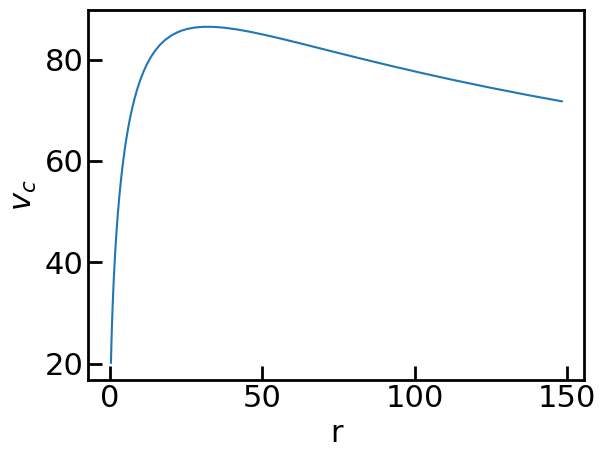

In [11]:
#Plot vcirc
r = res.Rs().value
vcirc = np.sqrt(res.vc2().value)
plt.plot(r, vcirc)
plt.ylabel(r'$v_c$')
plt.xlabel('r')

##Get vc from particle file

In [15]:
G = const.G.cgs.value 
kpc = (1 * u.kpc).to(u.cm).value
kmps = (1 * u.km / u.s).to(u.cm / u.s).value 

In [18]:
path_to_particle_file = '/Users/aditivijayan/quokka/INCITE/dwGal_setup/GalIC'
file_name = 'LMC_1000sol.txt'
infile = os.path.join(path_to_particle_file, file_name)
x, y, z, mass= np.loadtxt(infile, dtype=float, comments='#', delimiter=None, skiprows=1, usecols=(0, 1, 2,3), unpack=True)

In [19]:
rad = (x**2 + y**2 + z**2)**0.5
sort_indices = np.argsort(rad)
rad_sorted = rad[sort_indices]
mass_sorted = mass[sort_indices]
r = np.logspace(-1, 4, 51) * kpc
mass_enclosed_r, bin_edges = np.histogram(rad_sorted, bins=r, weights=mass_sorted)
rmid = 0.5 * (bin_edges[1:] + bin_edges[:-1])

In [63]:
def calculate_vc(infile, Rvir):
    x, y, z, mass= np.loadtxt(infile, dtype=float, comments='#', delimiter=None, skiprows=1, usecols=(0, 1, 2,3), unpack=True)
    rad = (x**2 + y**2 + z**2)**0.5
    sort_indices = np.argsort(rad)
    rad_sorted   = rad[sort_indices]
    mass_sorted  = mass[sort_indices]
    
    r = np.logspace(-1, 3, 51) * kpc
    mass_at_r, bin_edges = np.histogram(rad_sorted, bins=r, weights=mass_sorted)
    mass_enclosed_r = np.cumsum(mass_at_r)
    
    rmid = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    
    vc2  = G * mass_enclosed_r /rmid
    vc   = vc2**0.5 / kmps
    rmask = (rmid>Rvir)
    rvir_index = np.argmin(np.abs(rmid - Rvir*kpc))
    
    vc_at_rvir = vc[rvir_index]
    vc[rmid > Rvir*kpc] = vc_at_rvir
    print(vc_at_rvir, rmid[rvir_index]/kpc)
    return rmid, vc

46.93278855869993 145.1574965508761


Text(0.5, 0, '$r$ [kpc]')

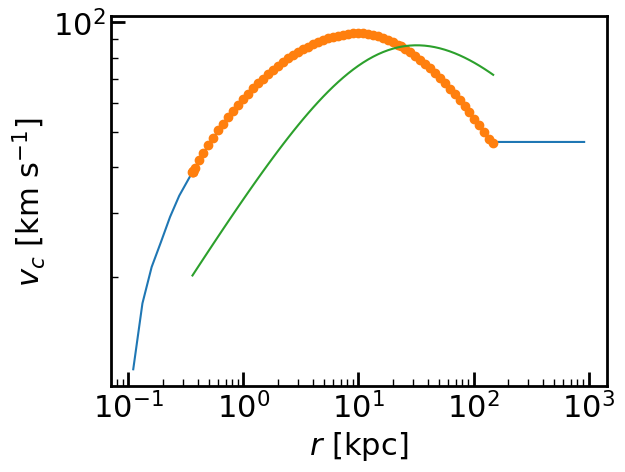

In [78]:
rmid, vc = calculate_vc(infile, Rvir)
log_vc_interp = interp1d(np.log10(rmid), np.log10(vc), kind="cubic", bounds_error=False, fill_value="extrapolate")
r = res.Rs().value * kpc
vc_at_r = 10.**log_vc_interp(np.log10(r))
vc_nfw = np.sqrt(res.vc2().value)
plt.plot(rmid/kpc, vc)
plt.plot(r/kpc, vc_at_r, 'o')
plt.plot(r/kpc, vc_nfw)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$v_c$ [km s$^{-1}$]')
plt.xlabel(r'$r$ [kpc]')



In [79]:
filename ='dwarf_halo_IC.dat'

r = res.Rs().value
rho = res.rhos().value
cs = res.cs().value 
v = res.vs().value 
vc = vc_at_r
T = cs * cs * mu * mp * kmps * kmps/gamma/kb
eint = (cs*kmps)**2 * rho/gamma/(gamma-1)
ekin = 0.5 * rho * (v*kmps)**2
etot = eint + ekin
rsonic = R_sonics[0].value
mom_r = rho * v

header = ("r[kpc] vc[km/s] rho v T"  f"Mdot[Msun/yr] = {Mdot*yr_to_sec/Msun:.6e} " f"rsonic[kpc] = {rsonic:.6e} "  f"Z2Zsun = {Z2Zsun:.2e} ")

data = np.column_stack([r, vc, rho, v, T ])
np.savetxt(filename, data, header=header, fmt="%.6e")

Norm= 0.0037465251478225824


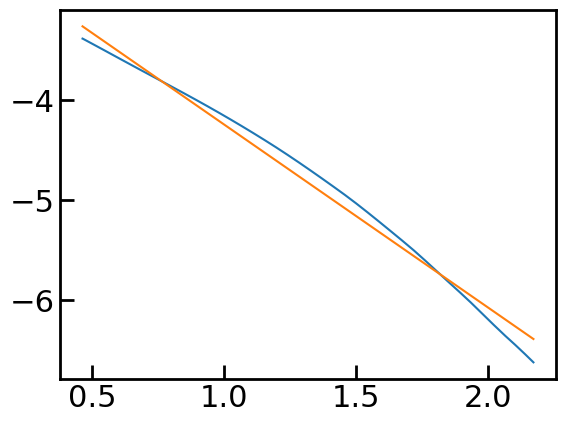

In [13]:
#Calculate normalisation of n_e

cloudy_H_mass_fraction = 1. / (1. + 0.1 * 3.971)
X = cloudy_H_mass_fraction
Z = 0.02  # metal fraction by mass
Y = 1. - X - Z
rhoH = rho * X
rho = rhoH / cloudy_H_mass_fraction
mean_metals_A = 16.
electron_mass_cgs = 9.1093897e-28
m_H = 1.672623e-24
mu = 0.6 
n_e = (rho / m_H) * (1.0 - mu * (X + Y / 4. + Z / mean_metals_A)) / \
                 (mu - ( electron_mass_cgs / m_H))
        

x = np.log10(res.Rs().value)
y = np.log10(n_e)
m,c = np.polyfit(x,y, deg=1)
yfit = m*x + c
plt.plot(x,y)
plt.plot(x,yfit)
print('Norm=', 10**c)